# PM2.5 Prediction Model

**Input:** `df_model_monthly.csv` built in `features.ipynb`.

| Model | Algorithm | Features                                              | Goal |
|---|---|-------------------------------------------------------|---|
| **A** | RF + XGBoost | environmental, spatial, contextual variables          | Policy story: what can municipalities act on? |
| **B** | RF | PM2.5 lags, rolling features, lagged pollutants, weather, context | Accuracy benchmark |
| **C** | Ridge | Same as A                                             | Linear baseline with signed coefficients |

**Two splits:** time (train past / test future) and spatial (train on some stations / test on unseen stations).

**Output:** `datasets/part3_predictions.csv` and `datasets/part3_model_metrics.csv` → used by `part4_policy_translation.ipynb`.

In [44]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
from xgboost import XGBRegressor

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

print("Libraries loaded")

Libraries loaded


## Load final modeling dataset

This CSV was created in `features.ipynb` and already contains:
- date
- station identifier (`eoi_code`)
- weather/context variables
- lag features
- rolling features

For now, we only use the columns needed for Model A.

In [ ]:
df = pd.read_csv("df_model_monthly.csv", parse_dates=["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Stations:", df["eoi_code"].nunique())

display(df.head())

In [ ]:
# Ensuring target exists, date is datetime, station id exists, PM2.5 has non-missing values
print("Target missing:", df["PM2_5"].isna().sum())
print("Date dtype:", df["date"].dtype)
print("Station id missing:", df["eoi_code"].isna().sum())

display(df[["date", "eoi_code", "PM2_5"]].head())

## Modeling dataset and splits

Before building individual models, we create one shared modeling dataset and one shared split setup.

This keeps Models A, B, and C fully comparable:
- same rows
- same target
- same station grouping
- same time split
- same spatial split

Filtering only on PM2.5 history features required by the forecasting setup.
We do not filter on pollutant lags like O3, because those reflect real sensor availability and would remove too many observations.

In [ ]:
required_history = [
    "PM2_5_lag1",
    "PM2_5_lag2",
    "PM2_5_lag3",
    "PM2_5_roll3_mean",
    "PM2_5_roll3_std"
]

df_model = df.dropna(subset=required_history).copy()

print("Rows before filtering:", len(df))
print("Rows after common history filter:", len(df_model))
print("Stations after filter:", df_model["eoi_code"].nunique())

display(df_model.head())

## Target and grouping variable

These objects will be reused by all models:
- `y` = PM2.5 target
- `groups` = station identifier for spatial split

In [ ]:
target_col = "PM2_5"
y = df_model[target_col].copy()
groups = df_model["eoi_code"].copy()

print("Filtered modeling shape:", df_model.shape)
print("Target shape:", y.shape)
print("Unique stations:", groups.nunique())

## Common train/test splits

We define the split and reuse it for all models.

### Time split
Train on earlier months, test on later months

In [ ]:
# Time split
cutoff_date = df_model["date"].quantile(0.8)
time_train_mask = df_model["date"] <= cutoff_date
time_test_mask = df_model["date"] > cutoff_date

print("Cutoff:", cutoff_date.date())
print("Train/test:", time_train_mask.sum(), time_test_mask.sum())

### Spatial split
Train on some stations, test on unseen stations

In [ ]:
# Spatial split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(df_model, y, groups=groups))

print("Spatial train/test rows:", len(tr_idx), len(te_idx))
print("Train stations:", df_model.iloc[tr_idx]["eoi_code"].nunique())
print("Test stations:", df_model.iloc[te_idx]["eoi_code"].nunique())

## Model A — RF + XGBoost (Explanatory)

### ⚠️ TO BUILD

Train RF and XGBoost on `features_a`. Pick champion by lowest average RMSE across both splits.

**Data ready to use:**
- `X_a` — built below
- `y`, `groups`, `time_train_mask`, `time_test_mask`, `tr_idx`, `te_idx` — shared from setup above
- `pre_a` — preprocessor built below

**XGBoost params:** `n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0`

**RF params:** `n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1`

**Variable names needed by comparison cell:**
- `pred_champ_a_t`, `pred_champ_a_s` — champion predictions on time/spatial test
- `m_champ_a_t`, `m_champ_a_s` — metrics dicts
- `champion_a_name` — string: `"RF"` or `"XGBoost"`
- `champ_a_full` — model retrained on full dataset (for SHAP / feature importance)

In [ ]:
# Model A feature set
# Keep this list simple and explicit.
# If a column name does not exist in df_model, it will be skipped safely.

candidate_features_a = [
    # Seasonality
    "Season",
    "month_sin",
    "month_cos",

    # Weather
    "Temp_Mean",
    "Wind_Speed",
    "Precipitation",

    # Lagged weather (still okay for explanatory model)
    "Temp_Mean_lag1",
    "Wind_Speed_lag1",
    "Precipitation_lag1",

    # Spatial
    "Altitude",
    "Latitude",
    "Longitude",
    "Green_Ratio",
    "Population_Density",

    # Contextual / station metadata
    "Station_Type",
    "Station_Area",
    "City"
]

features_a = [c for c in candidate_features_a if c in df_model.columns]

print("Model A features:", len(features_a))
print(features_a)


In [ ]:
def make_preprocessor(feature_list):
    num_cols = [c for c in feature_list if pd.api.types.is_numeric_dtype(df_model[c])]
    cat_cols = [c for c in feature_list if c not in num_cols]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

def reg_metrics(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }

pre_a = make_preprocessor(features_a)
print("Preprocessors and metrics helper ready")

### Build Model A feature matrix

We now create the feature matrix for Model A only.

Important:
- `y` is already shared
- split masks and indices are already shared
- only `X_a` is model-specific

In [ ]:
X_a = df_model[features_a].copy()

print("Model A X shape:", X_a.shape)
display(X_a.head())

# Reminder:
# y, groups, time_train_mask, time_test_mask, tr_idx, te_idx
# were already created in the shared setup section above.

## Model B — Random Forest (Environmental + PM2.5 History + Lagged Pollutants)

Accuracy benchmark. Adds PM2.5 lags, rolling stats, and lagged co-pollutants on top of all Model A features.
Comparing A vs B shows how much pollution memory and co-pollutant history improves forecasting.

In [ ]:
# Model B feature set
features_b = [
    "PM2_5_lag1", "PM2_5_lag2", "PM2_5_lag3", "PM2_5_roll3_mean", "PM2_5_roll3_std",
    "PM10_lag1", "NO2_lag1", "O3_lag1",
    "Temp_Mean", "Wind_Speed", "Precipitation",
    "Temp_Mean_lag1", "Wind_Speed_lag1", "Precipitation_lag1",
    "month_sin", "month_cos",
    "Altitude", "Latitude", "Longitude",
    "Green_Ratio", "Population_Density",
    "Station_Type", "Station_Area",
]
features_b = [c for c in features_b if c in df_model.columns]
X_b = df_model[features_b].copy()
pre_b = make_preprocessor(features_b)

print("Model B features:", len(features_b))
print(features_b)

### Model B — Time split

In [38]:
X_train_b_t = X_b.loc[time_train_mask]
X_test_b_t = X_b.loc[time_test_mask]
y_train_t = y.loc[time_train_mask]
y_test_t = y.loc[time_test_mask]

rf_b = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b.fit(X_train_b_t, y_train_t)
pred_rf_b_t = rf_b.predict(X_test_b_t)
m_rf_b_t = reg_metrics(y_test_t, pred_rf_b_t)
print("Model B time split:", m_rf_b_t)

Model B time split: {'MAE': 4.306216265164847, 'RMSE': 10.458876657735399, 'R2': 0.29024524666100837}


### Model B — Spatial split

In [36]:
X_train_b_s = X_b.iloc[tr_idx]
X_test_b_s = X_b.iloc[te_idx]
y_train_s = y.iloc[tr_idx]
y_test_s = y.iloc[te_idx]

rf_b_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_s.fit(X_train_b_s, y_train_s)
pred_rf_b_s = rf_b_s.predict(X_test_b_s)
m_rf_b_s = reg_metrics(y_test_s, pred_rf_b_s)
print("Model B spatial split:", m_rf_b_s)

Model B spatial split: {'MAE': 2.90375583858239, 'RMSE': 4.7465411010538245, 'R2': 0.6712502755727932}


In [37]:
metrics_b = pd.DataFrame([
    {"split": "time",    "model": "RandomForest_B", **m_rf_b_t},
    {"split": "spatial", "model": "RandomForest_B", **m_rf_b_s},
])
display(metrics_b)
metrics_b.to_csv("model_output/modelb_results.csv", index=False)
print("Saved to model_output/modelb_results.csv")

,split,model,MAE,RMSE,R2
0,time,RandomForest_B,4.306216,10.458877,0.290245
1,spatial,RandomForest_B,2.903756,4.746541,0.671250


Saved to model_metrics/modelb_results.csv


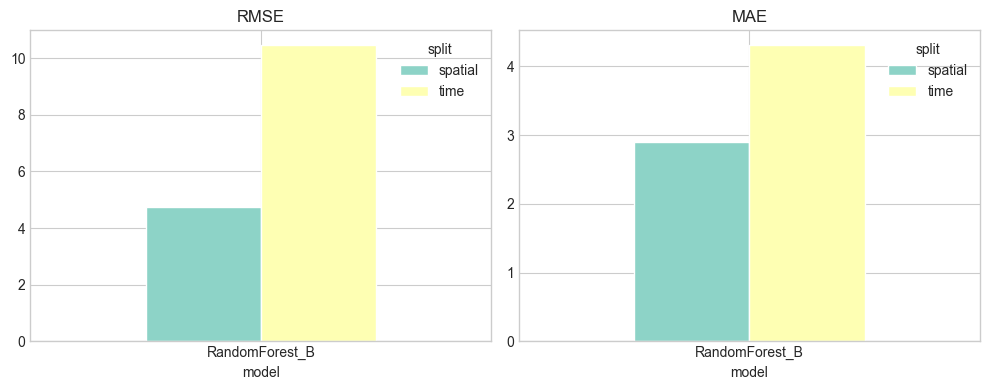

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["RMSE", "MAE"]):
    metrics_b.pivot(index="model", columns="split", values=metric).plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.legend(title="split")
plt.tight_layout()
plt.savefig("images/modelb_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

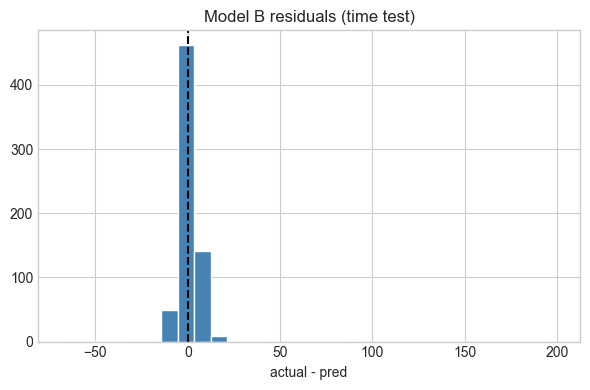

In [46]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
r = y_test_t.values - pred_rf_b_t
axes.hist(r, bins=30, color="steelblue", edgecolor="white")
axes.axvline(0, color="black", linestyle="--")
axes.set_title("Model B residuals (time test)")
axes.set_xlabel("actual - pred")
plt.tight_layout()
plt.savefig("images/modelb_residuals_time.png", dpi=150, bbox_inches="tight")
plt.show()

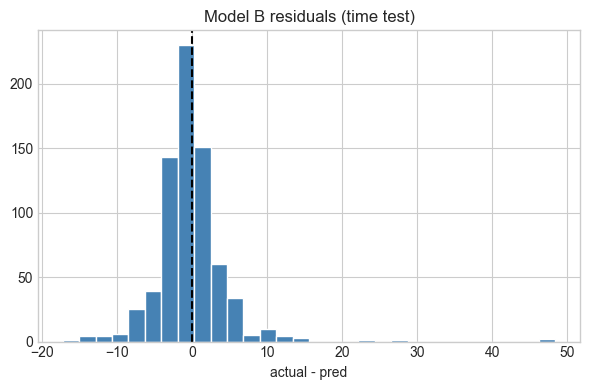

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
r = y_test_s.values - pred_rf_b_s
axes.hist(r, bins=30, color="steelblue", edgecolor="white")
axes.axvline(0, color="black", linestyle="--")
axes.set_title("Model B residuals (time test)")
axes.set_xlabel("actual - pred")
plt.tight_layout()
plt.savefig("images/modelb_residuals_space.png", dpi=150, bbox_inches="tight")
plt.show()

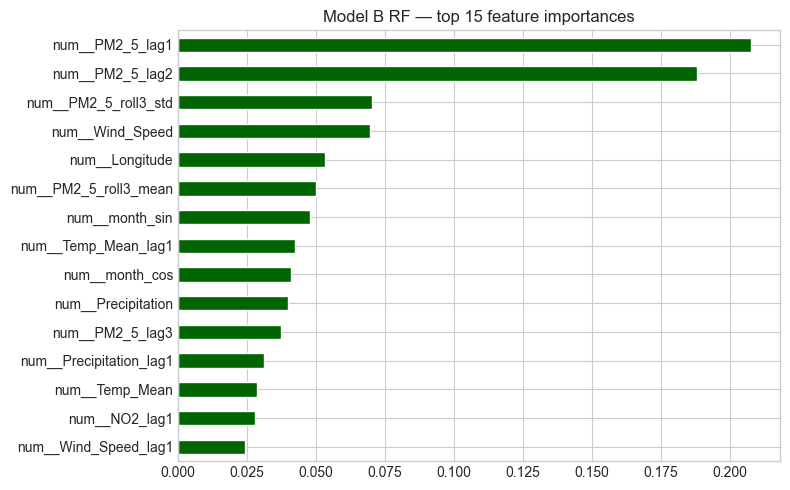

In [48]:
names = rf_b.named_steps["preprocess"].get_feature_names_out()
imp = pd.Series(rf_b.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Model B RF — top 15 feature importances")
plt.tight_layout()
plt.savefig("images/modelb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

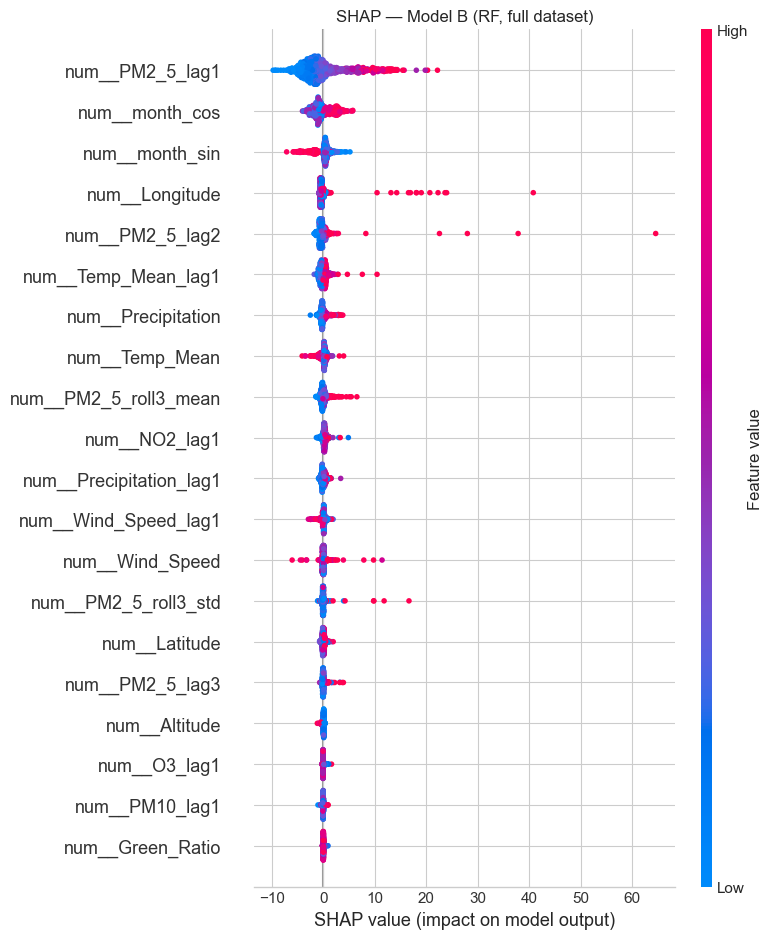

In [49]:
import scipy.sparse as sp
import shap

rf_b_full = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_full.fit(X_b, y)

Xp = rf_b_full.named_steps["preprocess"].transform(X_b)
if sp.issparse(Xp):
    Xp = Xp.toarray()
Xp = np.asarray(Xp, dtype=np.float64)

rng = np.random.RandomState(42)
idx = rng.choice(Xp.shape[0], size=min(800, Xp.shape[0]), replace=False)
Xs = Xp[idx]

explainer = shap.TreeExplainer(rf_b_full.named_steps["model"])
sv = explainer.shap_values(Xs)
fn = rf_b_full.named_steps["preprocess"].get_feature_names_out()

shap.summary_plot(sv, Xs, feature_names=fn, show=False)
plt.title("SHAP — Model B (RF, full dataset)")
plt.tight_layout()
plt.savefig("images/modelb_shap.png", dpi=150, bbox_inches="tight")
plt.show()

## Model C — Ridge Regression (Linear Baseline)

Same features as Model B. Ridge gives signed coefficients — positive = increases PM2.5, negative = decreases it.
Used to validate Model B SHAP directions with a simpler interpretable model.

In [ ]:
# Time split
ridge = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge.fit(X_train_b_t, y_train_t)
pred_ridge_t = ridge.predict(X_test_b_t)
m_ridge_t = reg_metrics(y_test_t, pred_ridge_t)
print("Model C (Ridge) time split:", m_ridge_t)

# Spatial split
ridge_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge_s.fit(X_train_b_s, y_train_s)
pred_ridge_s = ridge_s.predict(X_test_b_s)
m_ridge_s = reg_metrics(y_test_s, pred_ridge_s)
print("Model C (Ridge) spatial split:", m_ridge_s)

### Ridge Coefficients

In [ ]:
feat_names_c = ridge.named_steps["preprocess"].get_feature_names_out()
coef = pd.Series(
    ridge.named_steps["model"].coef_, index=feat_names_c
).sort_values(key=abs, ascending=False).head(15)

colors = ["#d73027" if v > 0 else "#4575b4" for v in coef.sort_values().values]
plt.figure(figsize=(9, 6))
coef.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Model C (Ridge) — Top 15 Coefficients\n(red = increases PM2.5 | blue = decreases)")
plt.tight_layout()
plt.savefig("images/model_c_ridge_coeff.png", dpi=150, bbox_inches="tight")
plt.show()